In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df_ml = pd.read_csv("Electricity_project/preprocessed_data.csv")
print(df_ml.shape)

(35040, 15)


In [2]:
df_ml.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'hour', 'day', 'month',
       'High_Usage'],
      dtype='object')

In [3]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  hour           

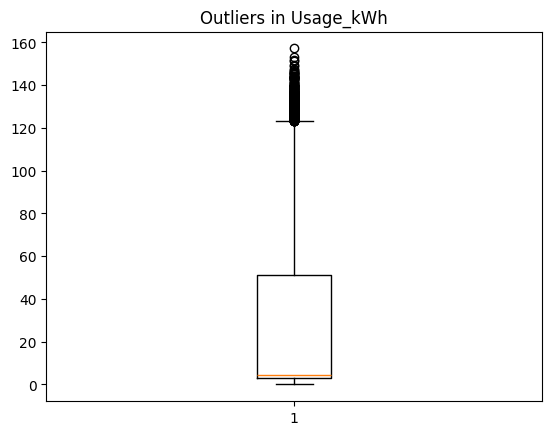

In [4]:
# Outlier Detection
import matplotlib.pyplot as plt
plt.boxplot(df_ml['Usage_kWh'])
plt.title("Outliers in Usage_kWh")
plt.show()

In [5]:
# OUTLIER TREATMENT (NUMERIC FEATURES ONLY)

In [6]:
numeric_cols = df_ml.select_dtypes(include=['float64', 'int64']).columns.tolist()
# High_Usage is bool, so it's not in numeric_cols – no need to remove

# IQR winsorization function
def iqr_winsorization(df, columns, thresh=1.5):
    df_out = df.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - thresh * IQR
        upper_fence = Q3 + thresh * IQR
        df_out[col] = df_out[col].clip(lower_fence, upper_fence)
    return df_out

# Apply outlier treatment
df_ml = iqr_winsorization(df_ml, numeric_cols)


In [7]:
## Check for outliers

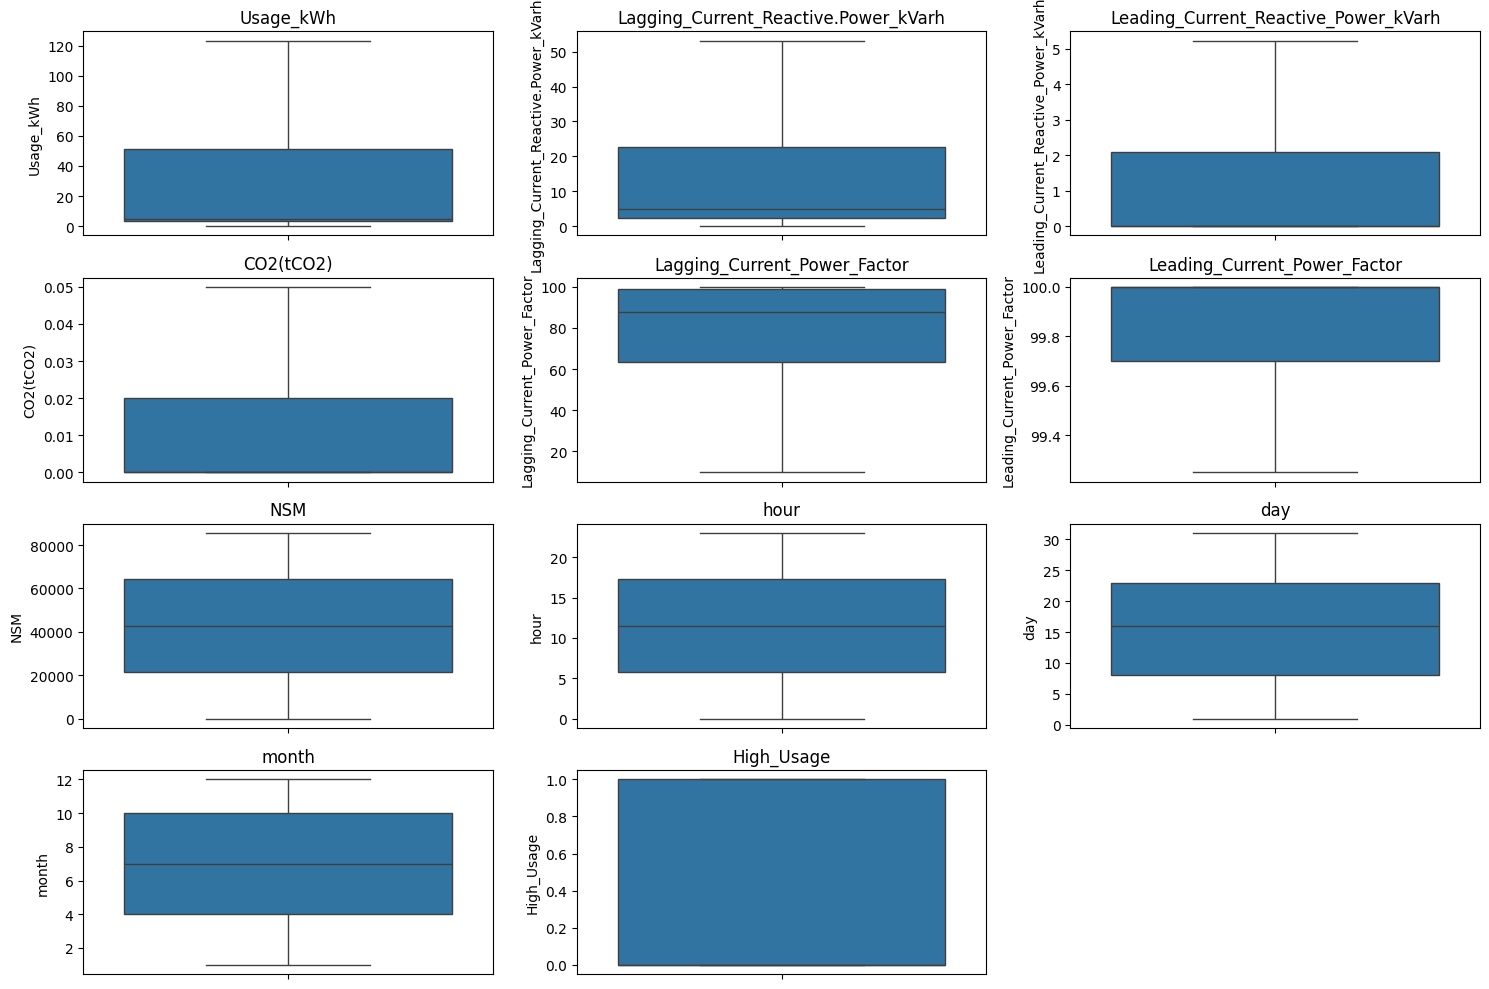

In [8]:
import seaborn as sns
numeric_features = [
    'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
    'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
    'NSM', 'hour', 'day', 'month', 'High_Usage'
]

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_features):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df_ml[col])
    plt.title(col)
plt.tight_layout()
plt.show()

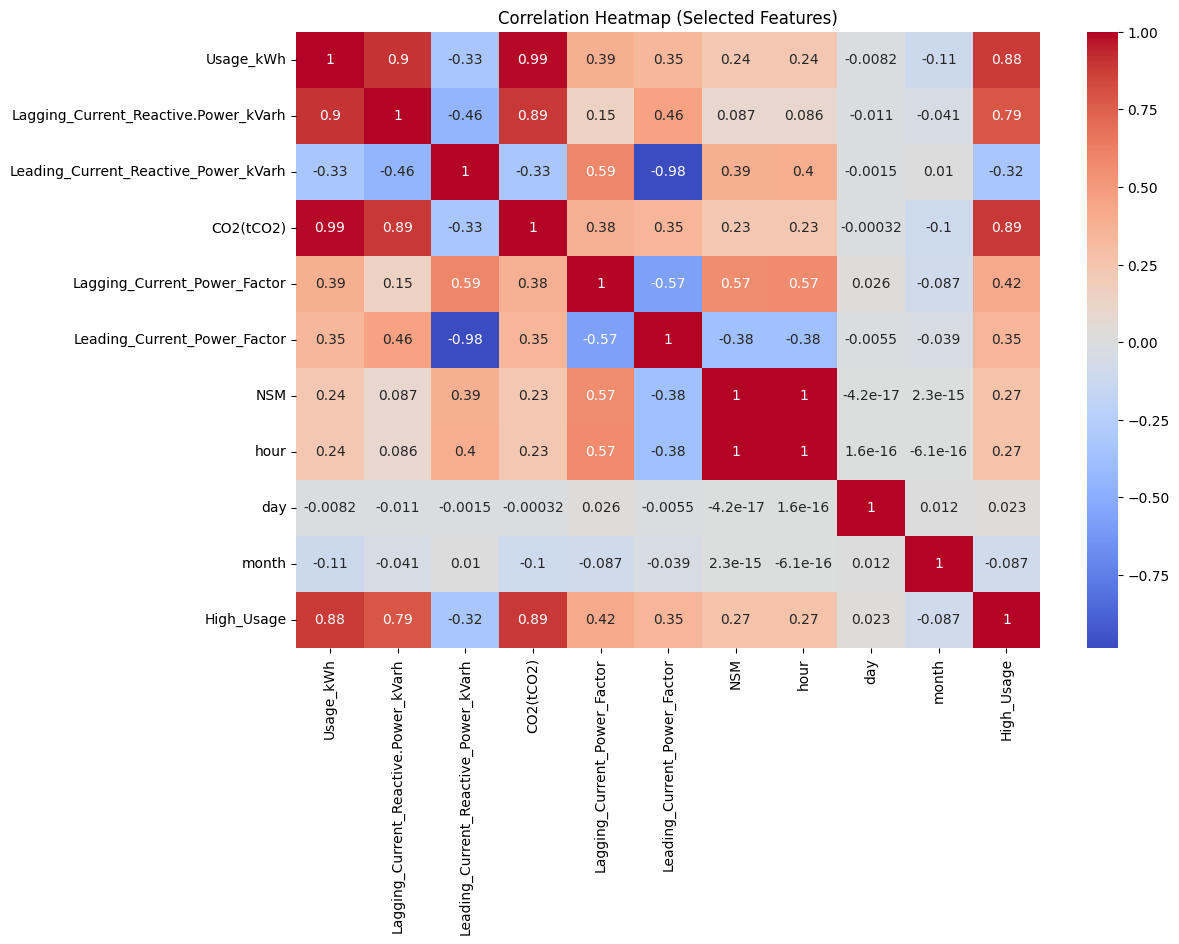

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of features you want in the heatmap
selected_features = [
    'Usage_kWh', 
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'NSM',
    'hour',
    'day',
    'month',
    'High_Usage'
]

# Subset the dataframe
subset_df = df_ml[selected_features]

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(subset_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [10]:
# Select numeric/boolean features
numeric_df = df_ml.select_dtypes(include=['float64', 'int64', 'bool'])

# Compute correlation with Usage_kWh
correlation_with_target = numeric_df.corr()['Usage_kWh'].sort_values(ascending=False)
print("Correlation of features with Usage_kWh:\n", correlation_with_target)

Correlation of features with Usage_kWh:
 Usage_kWh                               1.000000
CO2(tCO2)                               0.987095
Lagging_Current_Reactive.Power_kVarh    0.899801
High_Usage                              0.882029
Lagging_Current_Power_Factor            0.387469
Leading_Current_Power_Factor            0.345943
NSM                                     0.235705
hour                                    0.235263
day                                    -0.008173
month                                  -0.112782
Leading_Current_Reactive_Power_kVarh   -0.326617
Name: Usage_kWh, dtype: float64


In [11]:
df_ml.dtypes

date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
hour                                      int64
day                                       int64
month                                     int64
High_Usage                                 bool
dtype: object

## Linear Regression

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Load dataset
df = df_ml  # assuming your dataframe is already loaded

# Feature Encoding

In [13]:
import pandas as pd
# One-hot encoding categorical variables
df_encoded = pd.get_dummies(df_ml, columns=['WeekStatus', 'Day_of_week', 'Load_Type'], drop_first=True)

In [14]:
df_encoded.dtypes

date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
hour                                      int64
day                                       int64
month                                     int64
High_Usage                                 bool
WeekStatus_Weekend                         bool
Day_of_week_Monday                         bool
Day_of_week_Saturday                       bool
Day_of_week_Sunday                         bool
Day_of_week_Thursday                       bool
Day_of_week_Tuesday                        bool
Day_of_week_Wednesday                      bool
Load_Type_Maximum_Load                     bool
Load_Type_Medium_Load                   

In [15]:
# Feature Selection

In [16]:
# Selecting features
X = df_encoded.drop('Usage_kWh', axis=1)  # independent variables
y = df_encoded['Usage_kWh']               # target

In [17]:
# Feature Scaling

In [18]:
print(X.dtypes)

date                                     object
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
hour                                      int64
day                                       int64
month                                     int64
High_Usage                                 bool
WeekStatus_Weekend                         bool
Day_of_week_Monday                         bool
Day_of_week_Saturday                       bool
Day_of_week_Sunday                         bool
Day_of_week_Thursday                       bool
Day_of_week_Tuesday                        bool
Day_of_week_Wednesday                      bool
Load_Type_Maximum_Load                     bool
Load_Type_Medium_Load                      bool
dtype: object


In [19]:
X = X.drop('date', axis=1)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
#Check Multicollinearity

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print(vif_data.sort_values(by='VIF', ascending=False))

C:\Users\Baskar\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                 Feature         VIF
13                    Day_of_week_Sunday         inf
12                  Day_of_week_Saturday         inf
10                    WeekStatus_Weekend         inf
6                                   hour  618.301919
5                                    NSM  616.476328
4           Leading_Current_Power_Factor   38.266182
1   Leading_Current_Reactive_Power_kVarh   36.866378
2                              CO2(tCO2)   11.256654
9                             High_Usage    6.963230
0   Lagging_Current_Reactive.Power_kVarh    6.688250
3           Lagging_Current_Power_Factor    5.379245
18                 Load_Type_Medium_Load    2.555679
17                Load_Type_Maximum_Load    2.502916
11                    Day_of_week_Monday    1.728618
16                 Day_of_week_Wednesday    1.718254
15                   Day_of_week_Tuesday    1.717422
14                  Day_of_week_Thursday    1.716690
8                                  month    1.

In [23]:
# Split Data for Training and Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [24]:
# Train Multiple Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Intercept and coefficients
intercept = lr.intercept_
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})

print("Intercept:", intercept)
print(coefficients)

Intercept: 27.329693897543343
                                 Feature  Coefficient
0   Lagging_Current_Reactive.Power_kVarh     5.198553
1   Leading_Current_Reactive_Power_kVarh    -0.329761
2                              CO2(tCO2)    27.000142
3           Lagging_Current_Power_Factor     2.190807
4           Leading_Current_Power_Factor     0.837364
5                                    NSM    -1.709028
6                                   hour     1.532872
7                                    day    -0.282534
8                                  month    -0.543179
9                             High_Usage    -0.752089
10                    WeekStatus_Weekend     0.010582
11                    Day_of_week_Monday    -0.037022
12                  Day_of_week_Saturday    -0.035995
13                    Day_of_week_Sunday     0.049661
14                  Day_of_week_Thursday     0.001273
15                   Day_of_week_Tuesday     0.213284
16                 Day_of_week_Wednesday     0.01803

In [25]:
# Predict and Evaluate

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

MSE: 20.57
RMSE: 4.54
MAE: 2.78
R2 Score: 0.98


In [27]:
# Check Assumptions

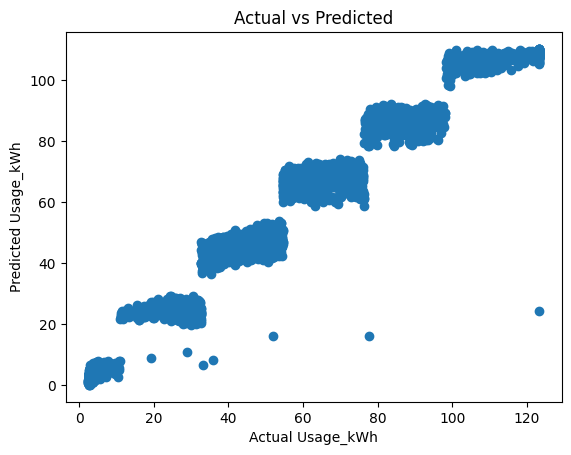

In [28]:
# Linearity – predicted vs actual:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Usage_kWh")
plt.ylabel("Predicted Usage_kWh")
plt.title("Actual vs Predicted")
plt.show()

In [29]:
# Residual Normality

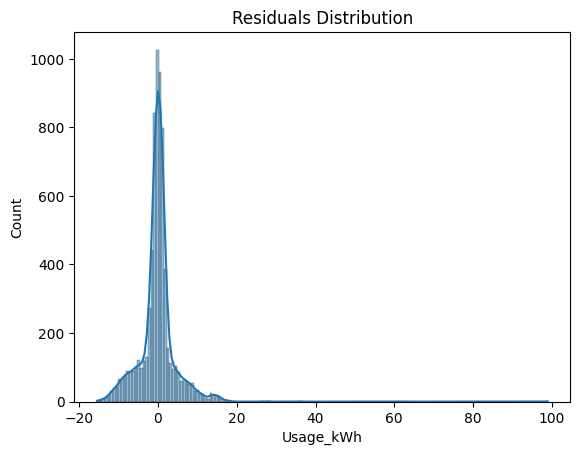

In [30]:
import seaborn as sns
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()

In [31]:
#Homoscedasticity

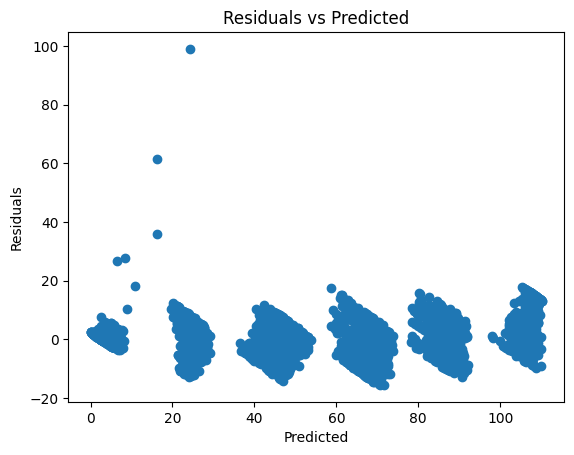

In [32]:
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

workflow ensures you cover:

Encoding categorical features
Scaling numeric features
Feature selection
Multicollinearity check
Data splitting
Model training
Intercept & slope
Performance metrics (MSE, RMSE, MAE, R²)
Assumptions check (linearity, residuals, homoscedasticity)

In [33]:
## interpretation

## logistic Regression

## problem statement 
### The main goal of this model is to identify high electricity usage periods in advance.
This helps the company to:
Reduce electricity cost 
Avoid peak load penalties 
Improve energy planning 
Reduce carbon emissions 

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [35]:
# remove target and date
X = df_ml.drop(['High_Usage', 'date', 'Usage_kWh', 'CO2(tCO2)'], axis=1)
y = df_ml['High_Usage'].astype(int)  # convert boolean to 0/1

In [36]:
# Encode categorical variables

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
# : Feature Scaling

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# Split data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [42]:
#Train Logistic Regression

In [43]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:,1]  # probability for ROC-AUC

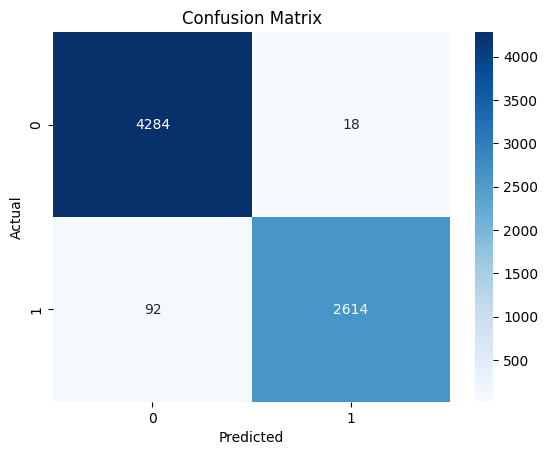

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [45]:

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.98
Precision: 0.99
Recall: 0.97
F1 Score: 0.98
ROC-AUC: 1.00


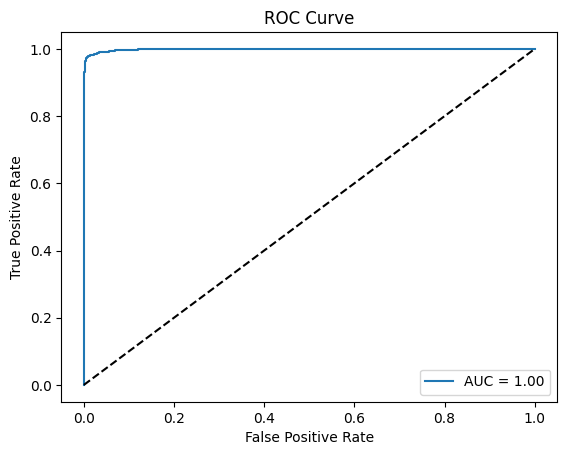

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## conclusion
### Our model predicts whether electricity usage will be high or low in advance.
### This enables the company to optimize energy usage, reduce operational costs, and prevent unexpected demand spikes.
### With highly accurate predictions, the model can act as a decision-support and early warning system for efficient energy managemen

## K MEANS CLUSTERING

## problem statement
## Businesses need to understand electricity usage patterns to reduce costs and improve efficiency.

## To minimize electrical utility penalties and reduce operational overhead
## by identifying periods of 'Power Quality Waste' where low energy usage is coupled with poor power factor efficiency."

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [48]:
#  Select Features for Clustering
features = ['Usage_kWh', 
            'Lagging_Current_Reactive.Power_kVarh', 
            'Leading_Current_Reactive_Power_kVarh', 
            'CO2(tCO2)', 
            'Lagging_Current_Power_Factor', 
            'Leading_Current_Power_Factor',
            'hour', 'day', 'month']
X = df_ml[features]

In [49]:
#  Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
# Find Optimal K using Elbow and Silhouette
sse = []
sil_scores = []
K = range(2, 10)
for k in K:
    kmodel = KMeans(n_clusters=k, random_state=42)
    labels = kmodel.fit_predict(X_scaled)
    sse.append(kmodel.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

Text(0.5, 1.0, 'Elbow Method')

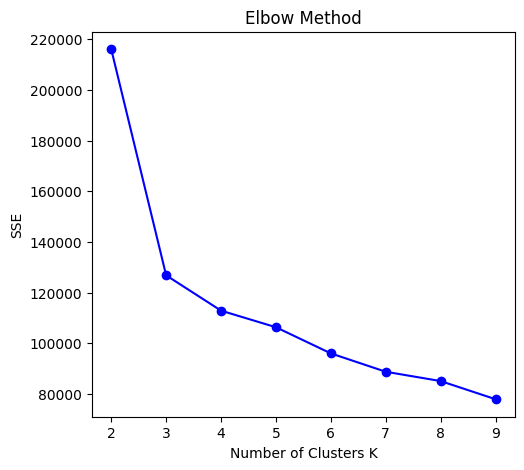

In [51]:
# Plot Elbow and Silhouette
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, sse, 'o-', color='blue')
plt.xlabel("Number of Clusters K")
plt.ylabel("SSE")
plt.title("Elbow Method")



In [52]:
#  Train Final KMeans Model (choose optimal K, e.g., 3)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df_ml['Cluster'] = kmeans_final.fit_predict(X_scaled)
# Cluster Centers (scaled back to original values)
centers = scaler.inverse_transform(kmeans_final.cluster_centers_)
print("Cluster Centers (original scale):\n", centers)

Cluster Centers (original scale):
 [[6.71614011e+01 3.03235087e+01 1.16904897e-01 3.05560502e-02
  9.02514245e+01 9.99952165e+01 1.37866451e+01 1.59803318e+01
  6.22541481e+00]
 [3.98789882e+00 4.95855041e+00 1.60997488e-02 2.21743811e-04
  6.01559466e+01 9.99895249e+01 6.54108360e+00 1.54853247e+01
  6.71187657e+00]
 [8.18068000e+00 5.07390857e-01 5.03370457e+00 2.12114286e-03
  9.94440446e+01 9.92682183e+01 1.61686857e+01 1.57283429e+01
  6.65451429e+00]]


In [53]:
# Evaluate Clusters
sil = silhouette_score(X_scaled, df_ml['Cluster'])
ch = calinski_harabasz_score(X_scaled, df_ml['Cluster'])
db = davies_bouldin_score(X_scaled, df_ml['Cluster'])

print(f"Silhouette Score: {sil:.3f}")
print(f"Calinski-Harabasz Index: {ch:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")


Silhouette Score: 0.440
Calinski-Harabasz Index: 26050.714
Davies-Bouldin Index: 0.954


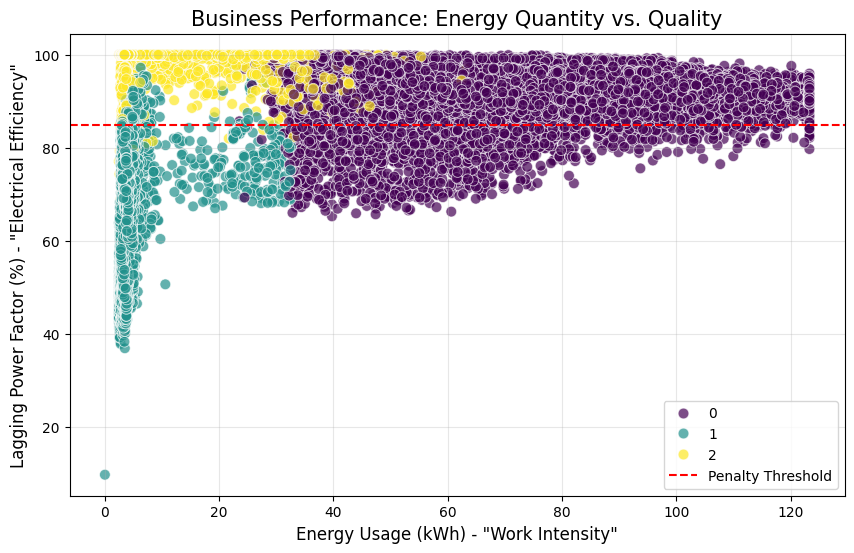

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using your 2 features: Usage_kWh and Lagging_Current_Power_Factor
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ml, x='Usage_kWh', y='Lagging_Current_Power_Factor', 
                hue='Cluster', palette='viridis', s=60, alpha=0.7)

plt.title('Business Performance: Energy Quantity vs. Quality', fontsize=15)
plt.xlabel('Energy Usage (kWh) - "Work Intensity"', fontsize=12)
plt.ylabel('Lagging Power Factor (%) - "Electrical Efficiency"', fontsize=12)
plt.axhline(85, color='red', linestyle='--', label='Penalty Threshold') # Standard utility benchmark
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## interpretation

## High-usage production shifts (Cluster 0) are electrically efficient, whereas low-usage "idle" periods (Cluster 2) suffer from severe power factor drops and financial penalties.
## By monitoring these distinct clusters, management can implement automated power factor correction to save costs during off-peak hours.

In [55]:
#  View Average Usage per Cluster
cluster_summary = df_ml.groupby('Cluster')[['Usage_kWh', 'CO2(tCO2)']].mean()
print("\nAverage Usage & CO2 per Cluster:\n", cluster_summary)


Average Usage & CO2 per Cluster:
          Usage_kWh  CO2(tCO2)
Cluster                      
0        67.150689   0.030552
1         3.986121   0.000221
2         8.171196   0.002115


## EDA BAsed on month

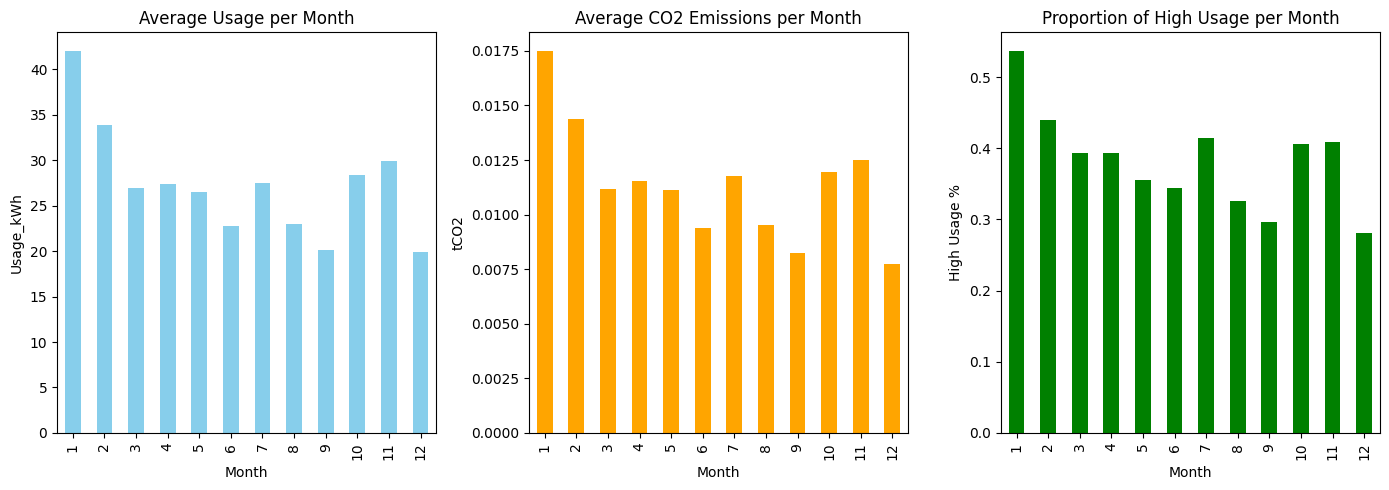

In [56]:
# Step 1: Average Usage per Month
monthly_usage = df_ml.groupby('month')['Usage_kWh'].mean()
monthly_co2 = df_ml.groupby('month')['CO2(tCO2)'].mean()
monthly_high_usage = df_ml.groupby('month')['High_Usage'].mean()  # proportion of high usage

# Step 2: Plotting
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
monthly_usage.plot(kind='bar', color='skyblue')
plt.title("Average Usage per Month")
plt.xlabel("Month")
plt.ylabel("Usage_kWh")

plt.subplot(1,3,2)
monthly_co2.plot(kind='bar', color='orange')
plt.title("Average CO2 Emissions per Month")
plt.xlabel("Month")
plt.ylabel("tCO2")

plt.subplot(1,3,3)
monthly_high_usage.plot(kind='bar', color='green')
plt.title("Proportion of High Usage per Month")
plt.xlabel("Month")
plt.ylabel("High Usage %")

plt.tight_layout()
plt.show()